# Practica 4 Resuelta: descenso de gradiente proyectado


In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["image.cmap"] = "viridis"


In [2]:
def rosenbrock(x, a=1.0, b=100.0):
    x = np.asarray(x, dtype=float)
    return np.sum((a - x[:-1]) ** 2 + b * (x[1:] - x[:-1] ** 2) ** 2)


def rosenbrock_grad(x, a=1.0, b=100.0):
    x = np.asarray(x, dtype=float)
    grad = np.zeros_like(x)
    diff = x[1:] - x[:-1] ** 2
    grad[:-1] += -2 * (a - x[:-1]) - 4 * b * x[:-1] * diff
    grad[1:] += 2 * b * diff
    return grad


def project_l2_ball(v, radius):
    norm = np.linalg.norm(v)
    if norm <= radius or norm == 0:
        return v.copy()
    return (radius / norm) * v


def soft_threshold(v, tau):
    return np.sign(v) * np.maximum(np.abs(v) - tau, 0.0)


def project_l1_ball(v, radius):
    if radius < 0:
        raise ValueError("El radio debe ser no negativo.")
    if np.linalg.norm(v, 1) <= radius:
        return v.copy()
    if radius == 0:
        return np.zeros_like(v)

    u = np.sort(np.abs(v))[::-1]
    cssv = np.cumsum(u)
    rho = np.nonzero(u * np.arange(1, len(v) + 1) > (cssv - radius))[0][-1]
    theta = (cssv[rho] - radius) / (rho + 1.0)
    return soft_threshold(v, theta)


def run_projected_gradient(
    x0,
    alpha,
    max_iter=5000,
    projection=None,
    radius=None,
    tol=1e-10,
    divergence_threshold=1e12,
):
    x = np.array(x0, dtype=float)
    if projection is not None:
        x = projection(x, radius)

    path = [x.copy()]
    values = [rosenbrock(x)]
    status = "max_iter"

    for _ in range(max_iter):
        x_next = x - alpha * rosenbrock_grad(x)
        if projection is not None:
            x_next = projection(x_next, radius)

        if (not np.isfinite(x_next).all()) or np.linalg.norm(x_next) > divergence_threshold:
            status = "diverged"
            break

        path.append(x_next.copy())
        values.append(rosenbrock(x_next))

        if np.linalg.norm(x_next - x) < tol:
            status = "converged"
            x = x_next
            break

        x = x_next

    return {
        "alpha": alpha,
        "radius": radius,
        "path": np.vstack(path),
        "values": np.array(values),
        "status": status,
        "iterations": len(values) - 1,
    }


def thin_path(path, max_points=400):
    if len(path) <= max_points:
        return path
    idx = np.linspace(0, len(path) - 1, max_points, dtype=int)
    return path[idx]


def print_summary(results, title):
    print(title)
    print(f"{'caso':>8} {'status':>10} {'iter':>8} {'f_final':>14} {'||x||_2':>12} {'||x||_1':>12}")
    for key, result in results.items():
        x_final = result["path"][-1]
        f_final = result["values"][-1]
        print(
            f"{str(key):>8} {result['status']:>10} {result['iterations']:8d} "
            f"{f_final:14.6e} {np.linalg.norm(x_final):12.6f} {np.linalg.norm(x_final, 1):12.6f}"
        )
    print()


x_plot = np.linspace(-2.0, 2.0, 250)
y_plot = np.linspace(-1.0, 3.0, 250)
X_plot, Y_plot = np.meshgrid(x_plot, y_plot)
Z_plot = (1 - X_plot) ** 2 + 100 * (Y_plot - X_plot ** 2) ** 2


def draw_rosenbrock_contours(ax):
    levels = np.geomspace(1e-2, 2e3, 18)
    ax.contour(X_plot, Y_plot, Z_plot, levels=levels, linewidths=0.8)
    ax.scatter([1], [1], color="red", s=45, label="minimo global")
    ax.set_xlim(-2.0, 2.0)
    ax.set_ylim(-1.0, 3.0)
    ax.set_xlabel("x")
    ax.set_ylabel("y")


def draw_l2_boundary(ax, radius):
    theta = np.linspace(0, 2 * np.pi, 400)
    ax.plot(radius * np.cos(theta), radius * np.sin(theta), "k--", linewidth=1)


def draw_l1_boundary(ax, radius):
    diamond = np.array([[radius, 0], [0, radius], [-radius, 0], [0, -radius], [radius, 0]])
    ax.plot(diamond[:, 0], diamond[:, 1], "k--", linewidth=1)


def draw_path(ax, result, label, color=None):
    path = thin_path(result["path"])
    ax.plot(path[:, 0], path[:, 1], marker="o", markersize=2.5, linewidth=1.5, label=label, color=color)
    ax.scatter(path[0, 0], path[0, 1], color=ax.lines[-1].get_color(), s=35, marker="s")
    ax.scatter(path[-1, 0], path[-1, 1], color=ax.lines[-1].get_color(), s=45, marker="X")


def plot_error_curves(ax, results, title):
    for label, result in results.items():
        values = np.maximum(result["values"], 1e-16)
        ax.semilogy(values, linewidth=2, label=str(label))
    ax.set_title(title)
    ax.set_xlabel("iteracion")
    ax.set_ylabel("error = f(x_k)")
    ax.legend()


## 1. Rosenbrock en 2 dimensiones



In [3]:
x0_2d = np.array([-1.5, 1.5])
alphas = [0.1, 0.01, 0.001]

runs_2d_unconstrained = {
    alpha: run_projected_gradient(x0_2d, alpha, max_iter=5000)
    for alpha in alphas
}

print_summary(runs_2d_unconstrained, "Resumen 2D sin restriccion")


Resumen 2D sin restriccion
    caso     status     iter        f_final      ||x||_2      ||x||_1
     0.1   diverged        2   1.302522e+28 3378502.907774 3416691.100000
    0.01   diverged        3   6.692938e+26 1608474.465826 1619338.870846
   0.001   max_iter     5000   4.950957e-03     1.269217     1.793743



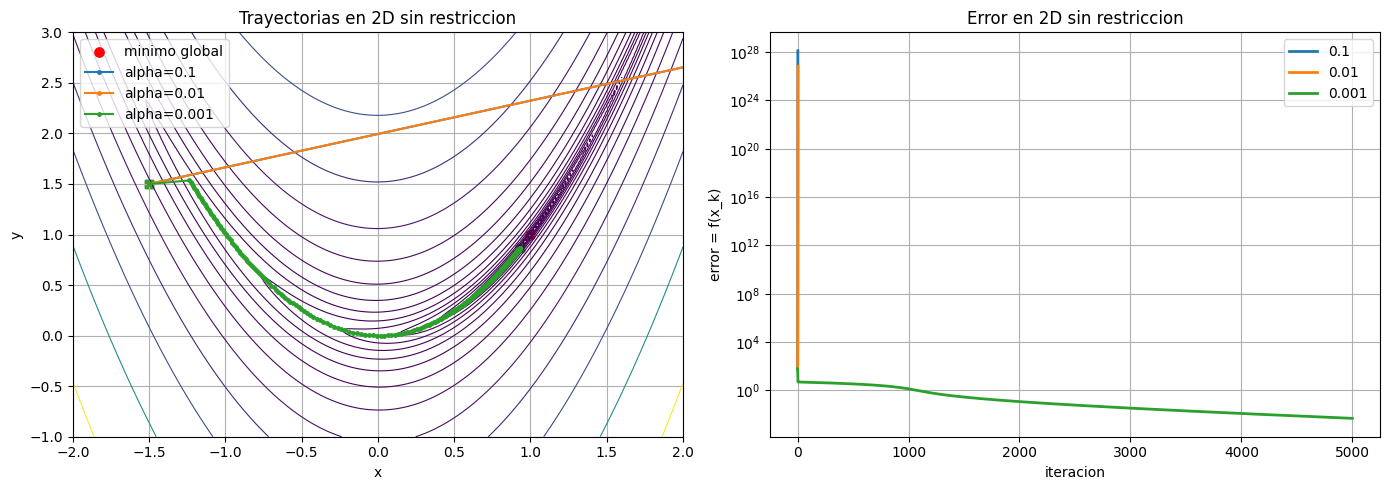

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

draw_rosenbrock_contours(axes[0])
for alpha, result in runs_2d_unconstrained.items():
    draw_path(axes[0], result, label=f"alpha={alpha}")
axes[0].set_title("Trayectorias en 2D sin restriccion")
axes[0].legend()

plot_error_curves(axes[1], runs_2d_unconstrained, "Error en 2D sin restriccion")

plt.tight_layout()
plt.show()


Los pasos `0.1` y `0.01` explotan muy rápido. Para estudiar las trayectorias proyectadas
en forma clara, usaremos `alpha=0.001`, que sí produce iteraciones estables.


In [5]:
alpha_stable = 0.001
radii = list(range(1, 11))

runs_2d_l2 = {
    r: run_projected_gradient(
        x0_2d,
        alpha_stable,
        max_iter=5000,
        projection=project_l2_ball,
        radius=r,
    )
    for r in radii
}

print_summary(runs_2d_l2, "Resumen 2D con proyeccion en bola L2")


Resumen 2D con proyeccion en bola L2
    caso     status     iter        f_final      ||x||_2      ||x||_1
       1  converged     2185   4.567481e-02     1.000000     1.404113
       2   max_iter     5000   4.719764e-03     1.272544     1.798503
       3   max_iter     5000   4.950957e-03     1.269217     1.793743
       4   max_iter     5000   4.950957e-03     1.269217     1.793743
       5   max_iter     5000   4.950957e-03     1.269217     1.793743
       6   max_iter     5000   4.950957e-03     1.269217     1.793743
       7   max_iter     5000   4.950957e-03     1.269217     1.793743
       8   max_iter     5000   4.950957e-03     1.269217     1.793743
       9   max_iter     5000   4.950957e-03     1.269217     1.793743
      10   max_iter     5000   4.950957e-03     1.269217     1.793743



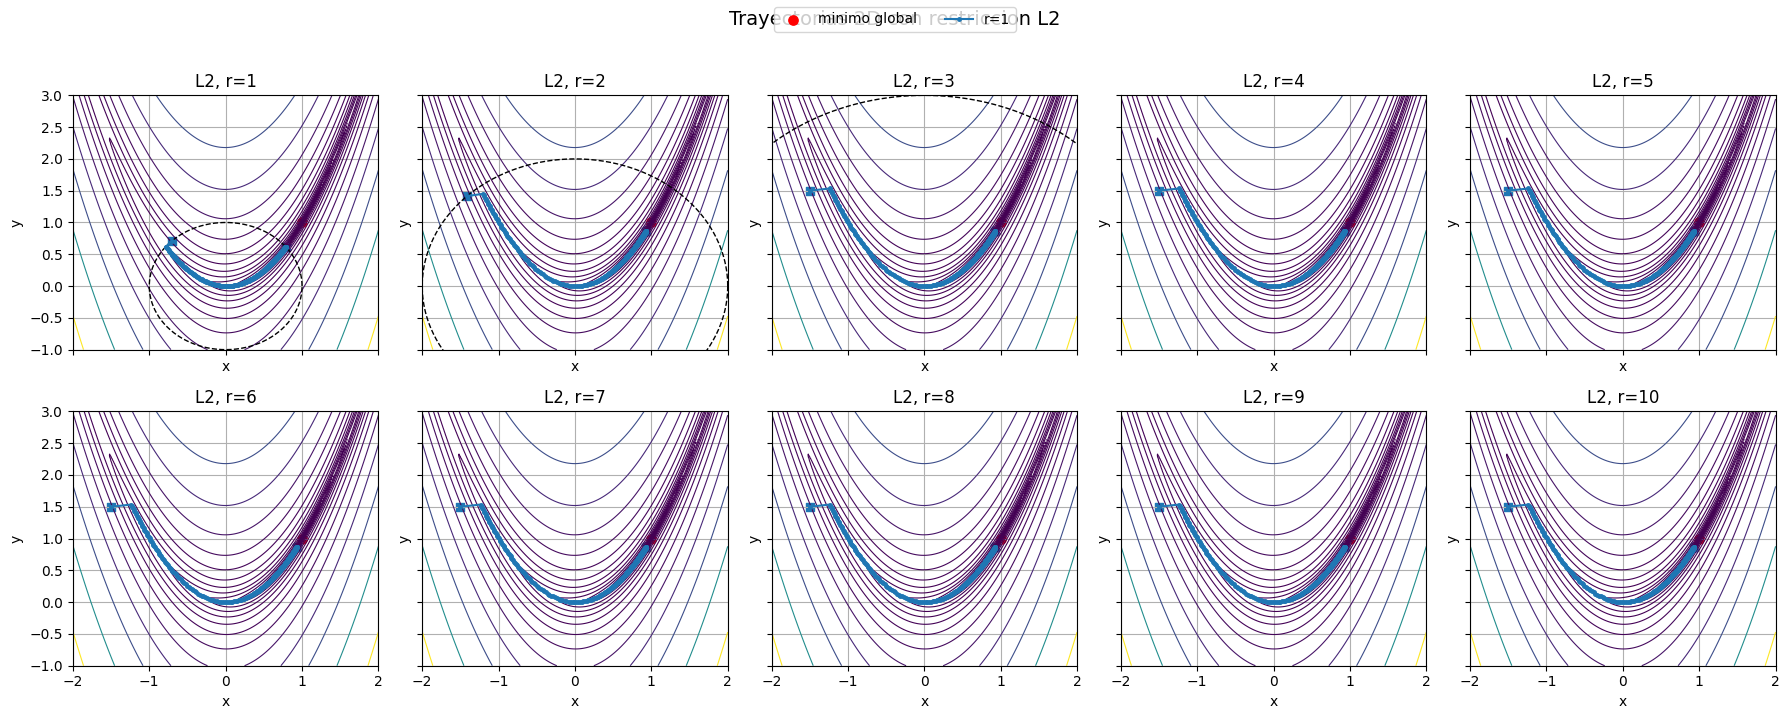

In [6]:
fig, axes = plt.subplots(2, 5, figsize=(18, 7), sharex=True, sharey=True)

for ax, r in zip(axes.ravel(), radii):
    draw_rosenbrock_contours(ax)
    draw_l2_boundary(ax, r)
    draw_path(ax, runs_2d_l2[r], label=f"r={r}")
    ax.set_title(f"L2, r={r}")

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=2)
fig.suptitle("Trayectorias 2D con restriccion L2", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()


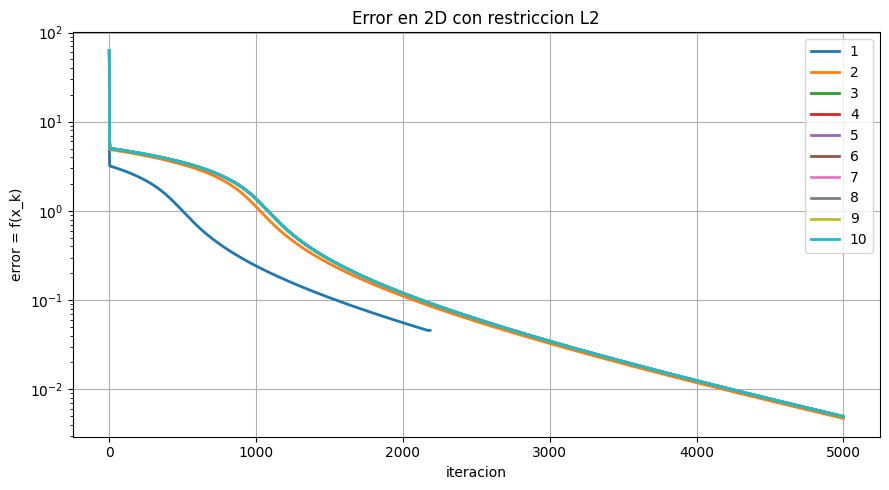

In [7]:
fig, ax = plt.subplots(figsize=(9, 5))
plot_error_curves(ax, runs_2d_l2, "Error en 2D con restriccion L2")
plt.tight_layout()
plt.show()


In [8]:
runs_2d_l1 = {
    r: run_projected_gradient(
        x0_2d,
        alpha_stable,
        max_iter=5000,
        projection=project_l1_ball,
        radius=r,
    )
    for r in radii
}

print_summary(runs_2d_l1, "Resumen 2D con proyeccion en bola L1")


Resumen 2D con proyeccion en bola L1
    caso     status     iter        f_final      ||x||_2      ||x||_1
       1  converged     1162   1.456070e-01     0.726791     1.000000
       2   max_iter     5000   3.627138e-03     1.289575     1.822849
       3   max_iter     5000   4.950957e-03     1.269217     1.793743
       4   max_iter     5000   4.950957e-03     1.269217     1.793743
       5   max_iter     5000   4.950957e-03     1.269217     1.793743
       6   max_iter     5000   4.950957e-03     1.269217     1.793743
       7   max_iter     5000   4.950957e-03     1.269217     1.793743
       8   max_iter     5000   4.950957e-03     1.269217     1.793743
       9   max_iter     5000   4.950957e-03     1.269217     1.793743
      10   max_iter     5000   4.950957e-03     1.269217     1.793743



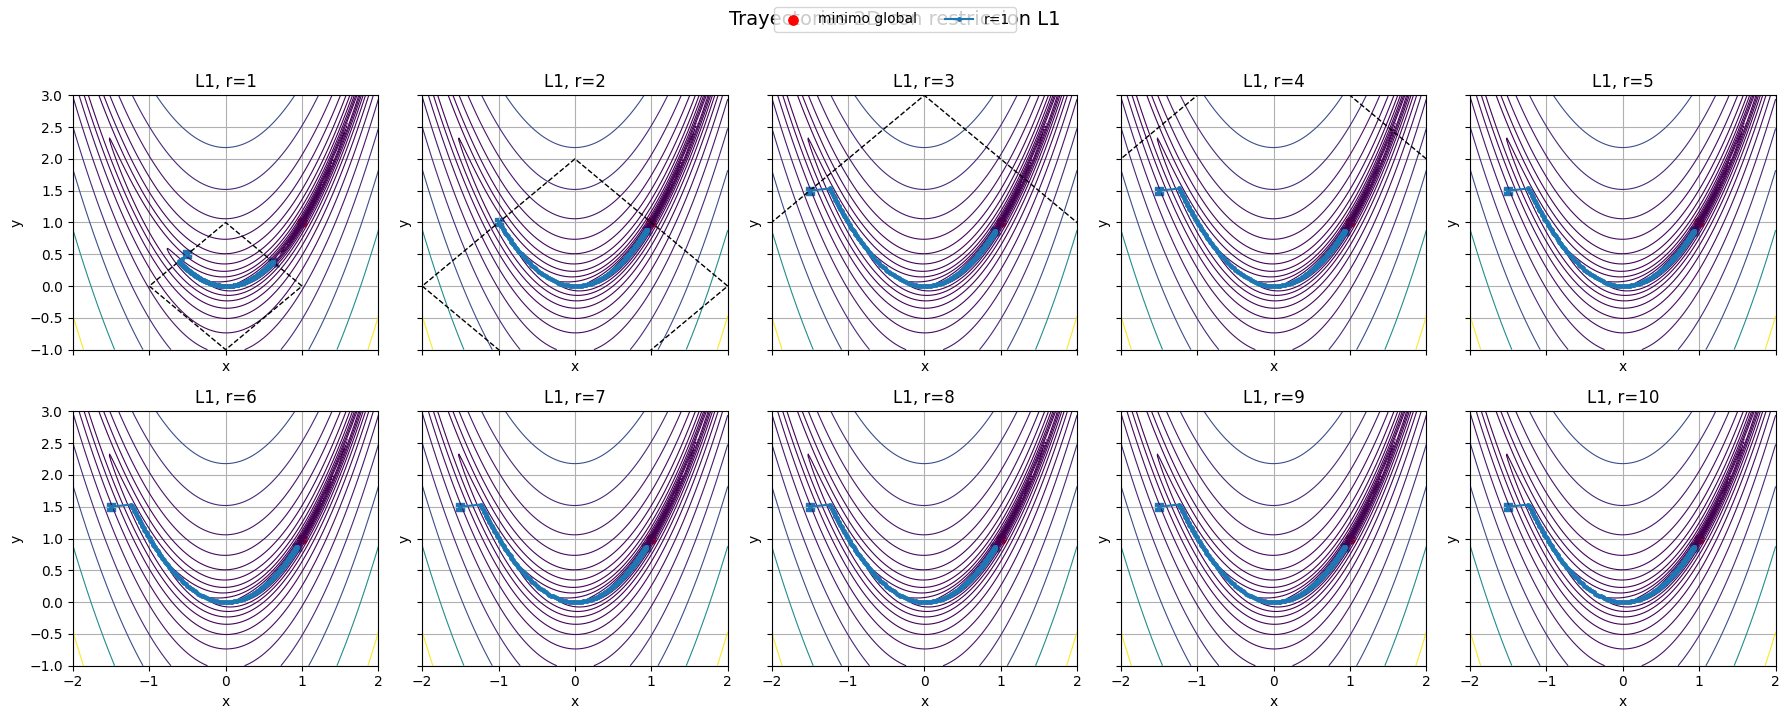

In [9]:
fig, axes = plt.subplots(2, 5, figsize=(18, 7), sharex=True, sharey=True)

for ax, r in zip(axes.ravel(), radii):
    draw_rosenbrock_contours(ax)
    draw_l1_boundary(ax, r)
    draw_path(ax, runs_2d_l1[r], label=f"r={r}")
    ax.set_title(f"L1, r={r}")

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=2)
fig.suptitle("Trayectorias 2D con restriccion L1", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()


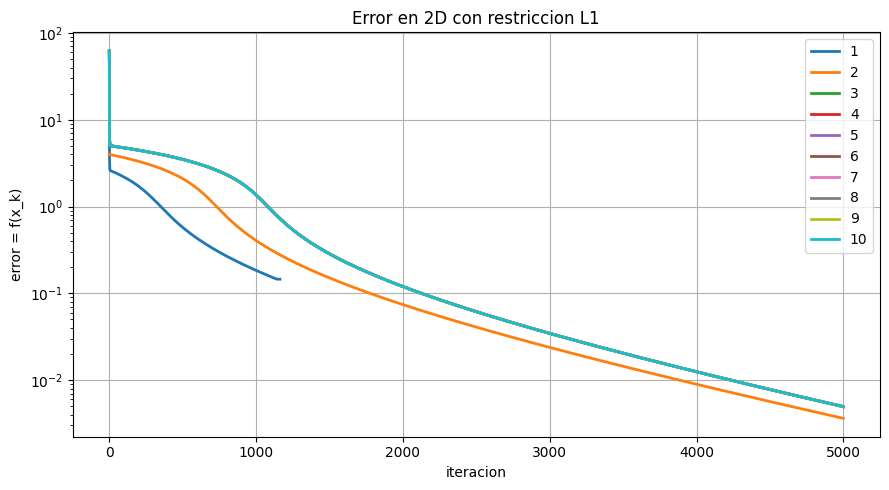

In [10]:
fig, ax = plt.subplots(figsize=(9, 5))
plot_error_curves(ax, runs_2d_l1, "Error en 2D con restriccion L1")
plt.tight_layout()
plt.show()


## 2. Rosenbrock en 100 dimensiones

En 100D ya no podemos visualizar la trayectoria en el espacio, así que nos concentramos en la
evolución del error.

Observación geométrica importante:

- `|| (1,...,1) ||_2 = 10`
- `|| (1,...,1) ||_1 = 100`

Por lo tanto, para radios `r=1,...,10`, el mínimo global sí entra en la bola `L2` solamente cuando
`r=10`, pero no entra en ninguna de las bolas `L1`.


In [11]:
x0_100d = np.tile(np.array([-1.2, 1.0]), 50)

runs_100d_unconstrained = {
    alpha: run_projected_gradient(x0_100d, alpha, max_iter=5000)
    for alpha in alphas
}

print_summary(runs_100d_unconstrained, "Resumen 100D sin restriccion")


Resumen 100D sin restriccion
    caso     status     iter        f_final      ||x||_2      ||x||_1
     0.1   diverged        2   7.050984e+32 152836947.614808 1458199950.944000
    0.01   diverged        3   1.673675e+43 54151684884.024971 433210260979.866028
   0.001   max_iter     5000   7.225109e+01     4.900294    25.747610



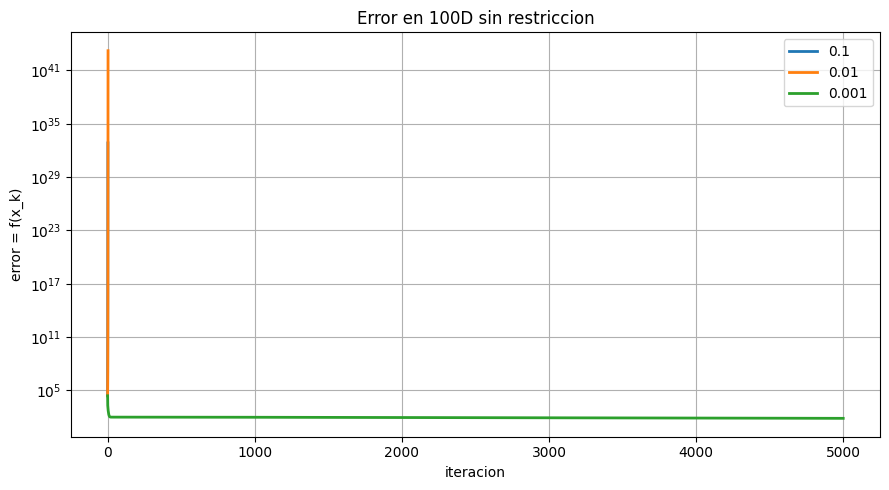

In [12]:
fig, ax = plt.subplots(figsize=(9, 5))
plot_error_curves(ax, runs_100d_unconstrained, "Error en 100D sin restriccion")
plt.tight_layout()
plt.show()


In [13]:
runs_100d_l2 = {
    r: run_projected_gradient(
        x0_100d,
        alpha_stable,
        max_iter=5000,
        projection=project_l2_ball,
        radius=r,
    )
    for r in radii
}

print_summary(runs_100d_l2, "Resumen 100D con proyeccion en bola L2")


Resumen 100D con proyeccion en bola L2
    caso     status     iter        f_final      ||x||_2      ||x||_1
       1  converged      641   9.553084e+01     1.000000     2.714493
       2  converged     1462   9.208699e+01     2.000000     5.938142
       3  converged     2699   8.703849e+01     3.000000    10.962212
       4  converged     4397   8.003700e+01     4.000000    17.962935
       5   max_iter     5000   7.151841e+01     4.975236    26.480225
       6   max_iter     5000   7.186070e+01     4.940367    26.137966
       7   max_iter     5000   7.210267e+01     4.915568    25.896017
       8   max_iter     5000   7.225564e+01     4.899825    25.743062
       9   max_iter     5000   7.232977e+01     4.892179    25.668946
      10   max_iter     5000   7.233057e+01     4.892096    25.668142



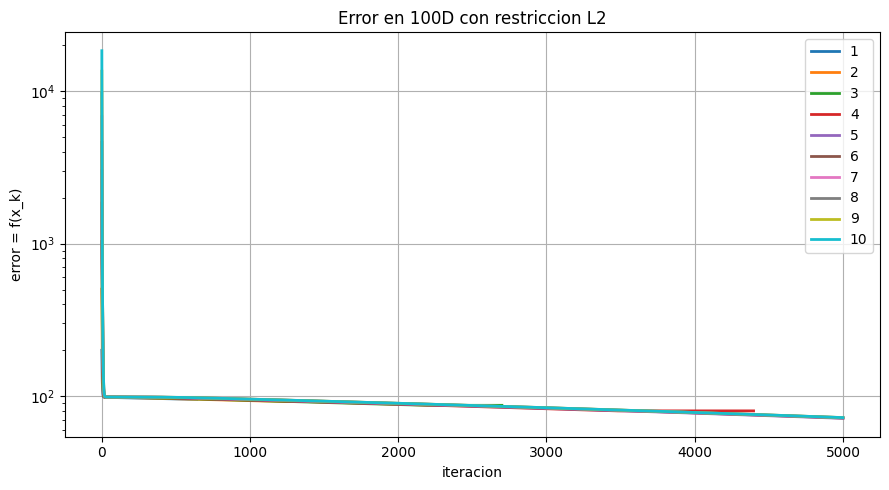

In [14]:
fig, ax = plt.subplots(figsize=(9, 5))
plot_error_curves(ax, runs_100d_l2, "Error en 100D con restriccion L2")
plt.tight_layout()
plt.show()


In [15]:
runs_100d_l1 = {
    r: run_projected_gradient(
        x0_100d,
        alpha_stable,
        max_iter=5000,
        projection=project_l1_ball,
        radius=r,
    )
    for r in radii
}

print_summary(runs_100d_l1, "Resumen 100D con proyeccion en bola L1")


Resumen 100D con proyeccion en bola L1
    caso     status     iter        f_final      ||x||_2      ||x||_1
       1  converged     2709   9.734024e+01     0.510451     1.000000
       2  converged     2325   9.604205e+01     0.942377     2.000000
       3  converged     2264   9.489875e+01     1.304804     3.000000
       4  converged     2331   9.382846e+01     1.615589     4.000000
       5  converged     2458   9.279367e+01     1.887888     5.000000
       6  converged     2613   9.177638e+01     2.131011     6.000000
       7  converged     2782   9.076777e+01     2.351551     7.000000
       8  converged     2957   8.976348e+01     2.554232     8.000000
       9  converged     3137   8.876134e+01     2.742493     9.000000
      10  converged     3318   8.776027e+01     2.918880    10.000000



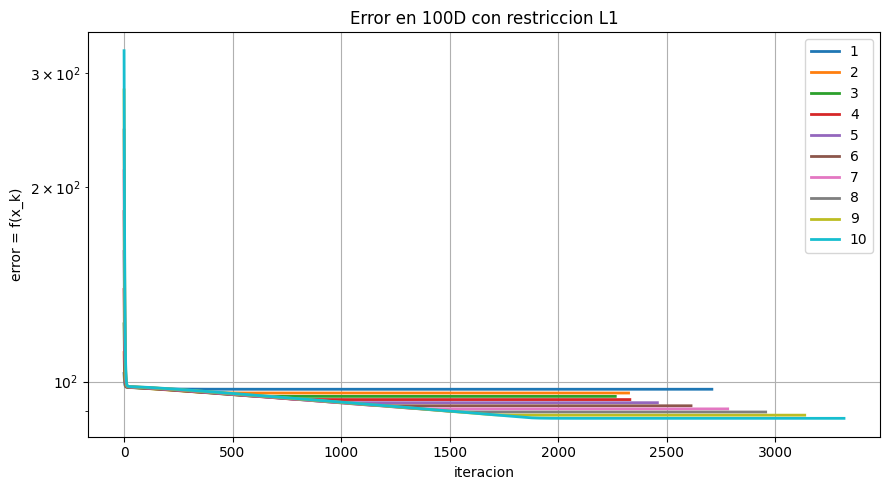

In [16]:
fig, ax = plt.subplots(figsize=(9, 5))
plot_error_curves(ax, runs_100d_l1, "Error en 100D con restriccion L1")
plt.tight_layout()
plt.show()
